QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

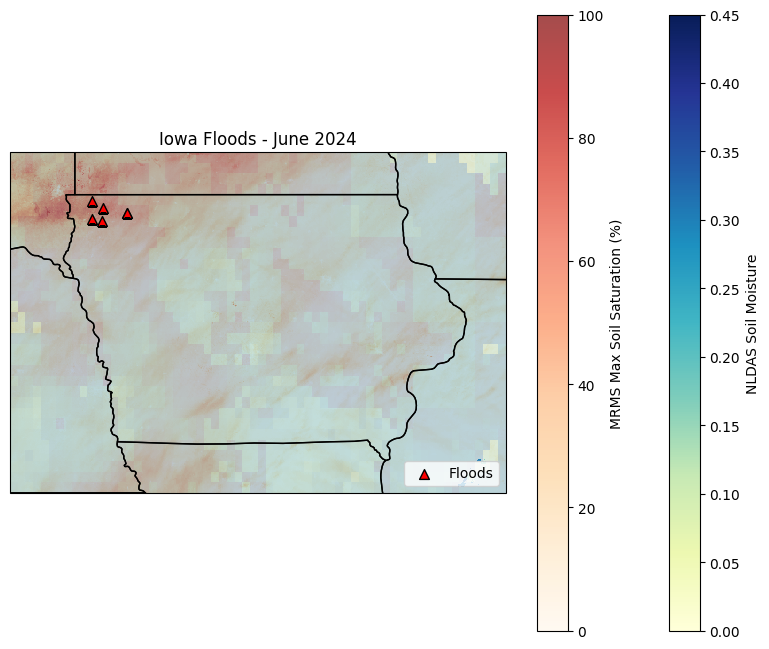

In [4]:
import urllib.request
import gzip
import tempfile
import xarray as xr
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import earthaccess

state = 'IA'
start_date = '2024-06-21'

url1 = "https://noaa-mrms-pds.s3.amazonaws.com/CONUS/FLASH_CREST_MAXSOILSAT_00.00/20240621/MRMS_FLASH_CREST_MAXSOILSAT_00.00_20240621-120000.grib2.gz"
response1 = urllib.request.urlopen(url1)
comp_data1 = response1.read()
temp1 = tempfile.NamedTemporaryFile(suffix=".grib2", delete=False)
temp1.write(gzip.decompress(comp_data1))
temp1.flush()
maxsoil = xr.load_dataarray(temp1.name, engine="cfgrib")

earthaccess.login(persist=True)
results = earthaccess.search_data(
    short_name="NLDAS_NOAH0125_H",
    version="2.0",
    temporal=("2024-06-21 12:00", "2024-06-21 13:00"),
    count=1)

files = earthaccess.download(results, "./nldas_data/")
ds_nldas = xr.open_dataset(files[0], engine="netcdf4")
nldas_soil = ds_nldas["SoilM_100_200cm"]

params = { 'state': 'IA',
    'sts': '2024-06-21T00:00:00Z',
    'ets': '2024-06-22T00:00:00Z',
    'fmt': 'csv'}

lsr_response = requests.get('https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py', params=params)
with open('lsr_list.csv', 'w', encoding='utf-8') as f:
    f.write(lsr_response.text)

df_lsr = pd.read_csv('lsr_list.csv', on_bad_lines='skip')
flood_df = df_lsr[df_lsr['TYPETEXT'].str.contains('FLOOD', na=False, case=False)]

geometry = [Point(xy) for xy in zip(flood_df['LON'], flood_df['LAT'])]
gdf_lsr = gpd.GeoDataFrame(flood_df, geometry=geometry, crs="EPSG:4326")
maxsoil['longitude'] = maxsoil['longitude'] - 360

mrms_crop = maxsoil.sel(latitude=slice(45, 39), longitude=slice(-98, -89))
nldas_vol = nldas_soil / 1000.0 
nldas_crop = nldas_vol.isel(time=0).sel(lat=slice(39, 45), lon=slice(-98, -89))

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

nldas_crop.plot(
    ax=ax, cmap="YlGnBu", vmin=0, vmax=0.45,
    cbar_kwargs={"label": "NLDAS Soil Moisture"})

mrms_crop.where(mrms_crop > 0).plot(
    ax=ax, cmap="OrRd", alpha=0.7, vmin=0, vmax=100,
    cbar_kwargs={"label": "MRMS Max Soil Saturation (%)"})

if not gdf_lsr.empty:
    gdf_lsr.plot(ax=ax, color='red', marker='^', markersize=50, edgecolor='black', label='Floods')
    plt.legend(loc='lower right')

ax.add_feature(cfeature.STATES)
ax.set_extent([-97.5, -89.5, 40.0, 44.0]) 
plt.title("Iowa Floods - June 2024")
plt.savefig("iowa_floods_2024.png")
plt.show()